In [8]:
#### Necessary libraries ####
import numpy as np  # Numpy is the fundamental package for scientific computing in Python.
import xarray as xr
import matplotlib.pyplot as plt  # Matplotlib is a scientific plotting package.
import cartopy.crs as ccrs
import cartopy
from cmocean import cm

from Functions import *
from combine_data import read_data
from paths import basedir, figure_path

# The statement below enforces the plots to be put into this notebook, instead of in their own windows.
%matplotlib inline

In [9]:
# Load results and masks
pak = read_data(basedir, "Pakistan")  # xr.open_dataset('./merged_Pakistan_v150724.nc')
aus = read_data(
    basedir, "Australia"
)  # xr.open_dataset('./merged_Australia_v150724.nc')
sct = read_data(basedir, "Scotland")  # xr.open_dataset('./merged_Scotland_v150724.nc')

mask_pak = xr.open_dataset(basedir + "/Pakistan/Mask_PakistanFlood_box_lon-180to180.nc")
mask_aus = xr.open_dataset(basedir + "/Australia/mask_australia_box_lon-180to180.nc")
mask_sct = xr.open_dataset(basedir + "/Scotland/mask_scotland_box_lon-180to180.nc")

Loading WRF-WVT data for Pakistan
Loading wam2layers data for Pakistan
Loading 2ldrm data for Pakistan
Loading utrack data for Pakistan
Loading btrims data for Pakistan
Loading tracmass data for Pakistan
Loading ughent data for Pakistan
Loading UIB data for Pakistan
Loading UniVie data for Pakistan
Loading CHc data for Pakistan
Loading xu data for Pakistan
Loading tatfancheng data for Pakistan
Loading uvigo data for Pakistan
Loading WRF-WVT data for Australia
Loading wam2layers data for Australia
Loading 2ldrm data for Australia
Loading utrack data for Australia
Loading btrims data for Australia
Loading tracmass data for Australia
Loading ughent data for Australia
Loading UIB data for Australia
Loading UniVie data for Australia
Loading CHc data for Australia
Loading xu data for Australia
Loading tatfancheng data for Australia
Loading uvigo data for Australia
Loading WRF-WVT data for Scotland
Loading wam2layers data for Scotland
Loading 2ldrm data for Scotland
Loading utrack data for Sc

In [10]:
# Select one ensemble member per method
drop_list = [
    "UTrack Ens1",
    "UTrack Ens3",
    "UTrack Ens4",
    "UTrack Ens5",
    "FLEXPART-SSW08 (HAMSTER) Ens1",
    "FLEXPART-SSW08 (HAMSTER) Ens2",
    "FLEXPART-SSW08 (HAMSTER) Ens3",
    "FLEXPART-SSW08 (HAMSTER) Ens4",
    "FLEXPART-SSW08 (HKUST) Ens1",
    "FLEXPART-SSW08 (HKUST) Ens3",
    "WRF-WVT",
]

pak = pak.drop_vars(drop_list)
aus = aus.drop_vars(drop_list)
sct = sct.drop_vars(drop_list)

## Absolute values of moisture sources [mm]

In [11]:
# Mean
pakm = pak.to_array(dim="mean").mean("mean")
ausm = aus.to_array(dim="mean").mean("mean")
sctm = sct.to_array(dim="mean").mean("mean")

# Standard variation
paks = pak.to_array(dim="std").std("std")
auss = aus.to_array(dim="std").std("std")
scts = sct.to_array(dim="std").std("std")

# Normalized Standard variation
pakn = paks / pakm
ausn = auss / ausm
sctn = scts / sctm

### Robinson projection

In [12]:
# MEAN
prj = ccrs.PlateCarree()
prjr = ccrs.Robinson(central_longitude=90, globe=None)
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": prjr})
pos = ax.get_position()
ax.set_position([0.125, pos.y0 + 0.05, 0.775, pos.height])

ax1 = fig.add_subplot(131)
ax1.set_axis_off()
ax2 = fig.add_subplot(132)
ax2.set_axis_off()
ax3 = fig.add_subplot(133)
ax3.set_axis_off()

ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)

p1 = pakm.plot.contourf(
    ax=ax,
    levels=np.linspace(0.5, 20.5, 21),
    extend="max",
    cmap=cm.speed,
    transform=prj,
    add_colorbar=False,
)
mask_pak.mask.plot.contour(ax=ax, colors="r", linewidths=1.5, transform=prj)
p2 = ausm.plot.contourf(
    ax=ax,
    levels=np.linspace(0.5, 24.5, 21),
    extend="max",
    cmap=cm.dense,
    transform=prj,
    add_colorbar=False,
)
mask_aus.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=1.5, transform=prj
)

p3 = sctm.plot.contourf(
    ax=ax,
    levels=np.linspace(0.5, 3.0, 26),
    extend="max",
    cmap=cm.matter,
    transform=prj,
    add_colorbar=False,
)
mask_sct.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=1.5, transform=prj
)

# Pakistan
ax.text(77, 35, r"$\bf{ Pakistan}$" + "\n10-24 Aug. 2022", fontsize=11, transform=prj)
# Australia
ax.text(155, -5, r"$\bf{ Australia}$" + "\n22-28 Feb. 2022", fontsize=11, transform=prj)
# Scotland
ax.text(-59, 56, r"$\bf{ Scotland}$" + "\n06-08 Oct. 2023", fontsize=11, transform=prj)

# ax.set_title(
#    "(a) Multi-method mean of accumulated tracked moisture", fontsize=14, loc="left"
# )

ax.set_title(
    "(a)",
    fontsize=14,
    loc="left",
    pad=-28,
)
ax.set_extent([-50, 230, -60, 80], crs=prj)
ax.gridlines(draw_labels=True)

fig.colorbar(p1, ax=ax2, orientation="horizontal").set_label(label="mm", size=12)
fig.colorbar(p2, ax=ax3, orientation="horizontal").set_label(label="mm", size=12)
fig.colorbar(p3, ax=ax1, orientation="horizontal").set_label(label="mm", size=12)

fig.savefig(
    figure_path + "Figure3_multimethodmean_revision.png", dpi=600, bbox_inches="tight"
)
# fig.savefig('Figure3a.pdf', format='pdf')

In [17]:
# STANDARD DEVIATION

prjr = ccrs.Robinson(central_longitude=90, globe=None)
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": prjr})
pos = ax.get_position()
ax.set_position([0.125, pos.y0 + 0.05, 0.775, pos.height])

ax1 = fig.add_subplot(131)
ax1.set_axis_off()
ax2 = fig.add_subplot(132)
ax2.set_axis_off()
ax3 = fig.add_subplot(133)
ax3.set_axis_off()

ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)

p1 = paks.plot.contourf(
    ax=ax,
    levels=np.linspace(0.5, 12.5, 25),
    extend="max",
    cmap=cm.speed,
    transform=prj,
    add_colorbar=False,
)
mask_pak.mask.plot.contour(ax=ax, colors="r", linewidths=1.5, transform=prj)

p2 = auss.plot.contourf(
    ax=ax,
    levels=np.linspace(0.5, 12.5, 25),
    extend="max",
    cmap=cm.dense,
    transform=prj,
    add_colorbar=False,
)
mask_aus.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=1.5, transform=prj
)

p3 = scts.plot.contourf(
    ax=ax,
    levels=np.linspace(0.3, 2.9, 25),
    extend="max",
    cmap=cm.matter,
    transform=prj,
    add_colorbar=False,
)
mask_sct.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=1.5, transform=prj
)

# Pakistan
ax.text(77, 35, r"$\bf{ Pakistan}$" + "\n10-24 Aug. 2022", fontsize=11, transform=prj)
# Australia
ax.text(155, -5, r"$\bf{ Australia}$" + "\n22-28 Feb. 2022", fontsize=11, transform=prj)
# Scotland
ax.text(-59, 56, r"$\bf{ Scotland}$" + "\n06-08 Oct. 2023", fontsize=11, transform=prj)

# ax.set_title(
#    "(b) Multi-method standard variation of accumulated tracked moisture [mm]",
#    fontsize=14,
#    loc="left",
# )

ax.set_title(
    "(b)",
    fontsize=14,
    loc="left",
    pad=-28,
)
ax.set_extent([-50, 230, -60, 80], crs=prj)
ax.gridlines(draw_labels=True)

fig.colorbar(p1, ax=ax2, orientation="horizontal").set_label(label="mm", size=12)
fig.colorbar(p2, ax=ax3, orientation="horizontal").set_label(label="mm", size=12)
fig.colorbar(p3, ax=ax1, orientation="horizontal").set_label(label="mm", size=12)

fig.savefig(
    figure_path + "Figure3b_multimethodstd_revision2.png", dpi=600, bbox_inches="tight"
)

# fig.savefig('Figure3b.pdf', format='pdf')

In [7]:
# Normalized Standard Deviation - without threshold
prjr = ccrs.Robinson(central_longitude=90, globe=None)
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": prjr})
pos = ax.get_position()
ax.set_position([0.125, pos.y0 + 0.05, 0.775, pos.height])

ax1 = fig.add_subplot(131)
ax1.set_axis_off()
ax2 = fig.add_subplot(132)
ax2.set_axis_off()
ax3 = fig.add_subplot(133)
ax3.set_axis_off()

ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)

vmax = 1.5
p1 = pakn.where(pakn < vmax).plot(
    ax=ax,
    vmin=0.1,
    vmax=vmax,
    cmap=cm.speed_r,
    transform=prj,
    add_colorbar=False,
)
mask_pak.mask.plot.contour(ax=ax, colors="r", linewidths=0.4, transform=prj)

p2 = ausn.where(ausn < vmax).plot(
    ax=ax,
    vmin=0.1,
    vmax=vmax,
    cmap=cm.dense_r,
    transform=prj,
    add_colorbar=False,
)
mask_aus.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=0.4, transform=prj
)

p3 = sctn.where(sctn < vmax).plot(
    ax=ax,
    vmin=0.1,
    vmax=vmax,
    cmap=cm.matter_r,
    transform=prj,
    add_colorbar=False,
)
mask_sct.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=0.4, transform=prj
)

# Pakistan
ax.text(77, 35, "10-24 Aug. 2022", fontsize=11, transform=prj)
# Australia
ax.text(155, -5, "22-28 Feb. 2022", fontsize=11, transform=prj)
# Scotland
ax.text(-59, 56, "06-08 Oct. 2023", fontsize=11, transform=prj)

ax.set_title(
    "(b) Multi-method normalized standard variation of accumulated tracked moisture [mm/mm]",
    fontsize=14,
    loc="left",
)
ax.set_extent([-50, 230, -60, 80], crs=prj)
ax.gridlines(draw_labels=True)

fig.colorbar(p1, ax=ax2, orientation="horizontal").set_label(label="Pakistan", size=12)
fig.colorbar(p2, ax=ax3, orientation="horizontal").set_label(label="Australia", size=12)
fig.colorbar(p3, ax=ax1, orientation="horizontal").set_label(label="Scotland", size=12)

# fig.savefig('Figure3b_n.pdf', format='pdf')

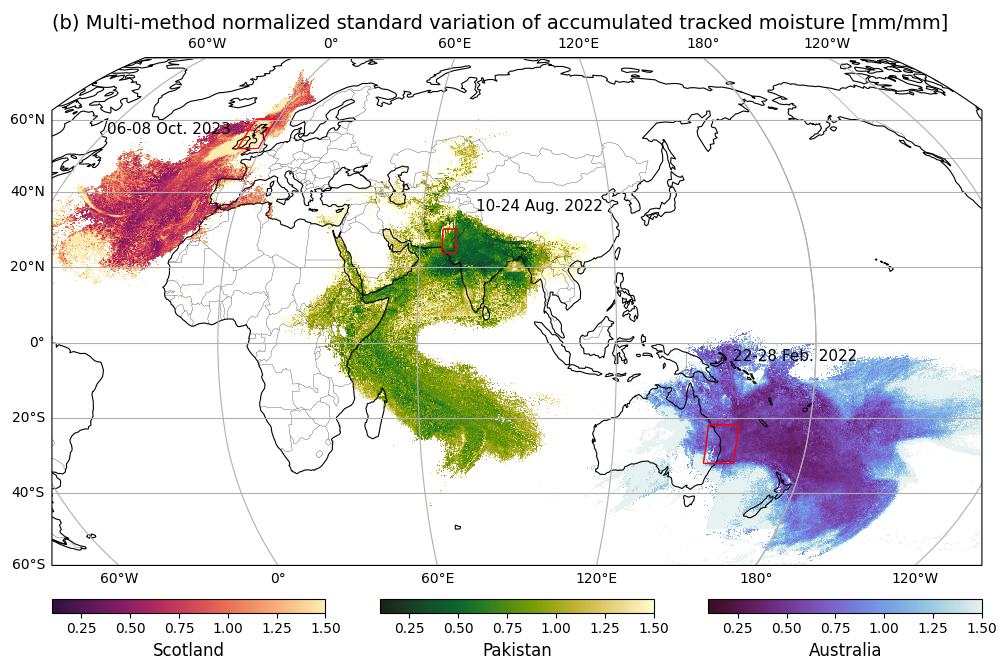

In [ ]:
# Normalized Standard Deviation - with threshold
prjr = ccrs.Robinson(central_longitude=90, globe=None)
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": prjr})
pos = ax.get_position()
ax.set_position([0.125, pos.y0 + 0.05, 0.775, pos.height])

ax1 = fig.add_subplot(131)
ax1.set_axis_off()
ax2 = fig.add_subplot(132)
ax2.set_axis_off()
ax3 = fig.add_subplot(133)
ax3.set_axis_off()

ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)

vmax = 1.5
mths = 0.2  # filter out normalized values by minimum mean values
p1 = pakn.where(pakm > mths).plot(
    ax=ax,
    vmin=0.1,
    vmax=vmax,
    cmap=cm.speed_r,
    transform=prj,
    add_colorbar=False,
)
mask_pak.mask.plot.contour(ax=ax, colors="r", linewidths=0.4, transform=prj)

p2 = ausn.where(ausm > mths).plot(
    ax=ax,
    vmin=0.1,
    vmax=vmax,
    cmap=cm.dense_r,
    transform=prj,
    add_colorbar=False,
)
mask_aus.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=0.4, transform=prj
)

p3 = sctn.where(sctm > mths).plot(
    ax=ax,
    vmin=0.1,
    vmax=vmax,
    cmap=cm.matter_r,
    transform=prj,
    add_colorbar=False,
)
mask_sct.mask.isel(time=0, drop=True).plot.contour(
    ax=ax, colors="r", linewidths=0.4, transform=prj
)

# Pakistan
ax.text(77, 35, "10-24 Aug. 2022", fontsize=11, transform=prj)
# Australia
ax.text(155, -5, "22-28 Feb. 2022", fontsize=11, transform=prj)
# Scotland
ax.text(-59, 56, "06-08 Oct. 2023", fontsize=11, transform=prj)

ax.set_title(
    "(b) Multi-method normalized standard variation of accumulated tracked moisture [mm/mm]",
    fontsize=14,
    loc="left",
)
ax.set_extent([-50, 230, -60, 80], crs=prj)
ax.gridlines(draw_labels=True)

fig.colorbar(p1, ax=ax2, orientation="horizontal").set_label(label="Pakistan", size=12)
fig.colorbar(p2, ax=ax3, orientation="horizontal").set_label(label="Australia", size=12)
fig.colorbar(p3, ax=ax1, orientation="horizontal").set_label(label="Scotland", size=12)

# fig.savefig('Figure3b_n_ths.pdf', format='pdf')